In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, shapiro, kruskal, mannwhitneyu, tukey_hsd, ttest_ind
from statsmodels.stats.oneway import anova_oneway

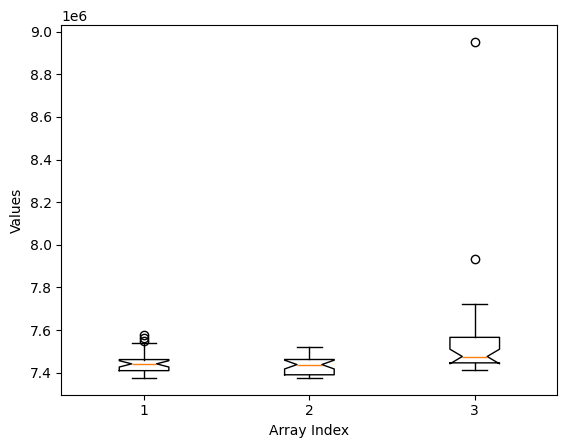

In [2]:
def plot_boxplots(filename):
    data = np.load(filename)
    outer_array = data[data.files[0]] # Extract the outer array
    
    # print(outer_array)

    plt.figure()
    plt.boxplot(outer_array.T, notch=True)  # Transpose the array for correct plotting
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

filename = 'data/best_FXs.npz'
plot_boxplots(filename)

In [12]:

filename = 'data/best_FXs.npz'
data = np.load(filename)
data = data["best_FX_values"]
a = data[0, :]
b = data[1, :]
c = data[2, :]
f_oneway(a, b, c)


F_onewayResult(statistic=6.051548105519163, pvalue=0.0034617307474180035)

In [13]:

print(shapiro(a))
print(shapiro(b))
print(shapiro(c))

ShapiroResult(statistic=0.9087280129294772, pvalue=0.013822797834162947)
ShapiroResult(statistic=0.9286979238538342, pvalue=0.04534945809874168)
ShapiroResult(statistic=0.48249651682232975, pvalue=3.5168258236191767e-09)


In [14]:

kruskal(a, b, c)

KruskalResult(statistic=18.178072446085864, pvalue=0.00011289682346383854)

In [17]:

print(mannwhitneyu(a, b))
print(mannwhitneyu(a, c, alternative='less'))
print(mannwhitneyu(b, c, alternative='less'))

MannwhitneyuResult(statistic=489.5, pvalue=0.5634386485835218)
MannwhitneyuResult(statistic=220.0, pvalue=0.00034414111160305266)
MannwhitneyuResult(statistic=186.5, pvalue=4.995895266461636e-05)


In [19]:

anova_oneway(data, use_var='unequal')

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 4.06301317517671
pvalue = 0.02313090098061361
df = (2.0, 50.33996510601357)
df_num = 2.0
df_denom = 50.33996510601357
nobs_t = 90.0
n_groups = 3
means = array([7447369.99385387, 7430648.10158997, 7569568.35700945])
nobs = array([30., 30., 30.])
vars_ = array([3.21157251e+09, 1.66038158e+09, 8.06703693e+10])
use_var = 'unequal'
welch_correction = True
tuple = (4.06301317517671, 0.02313090098061361)

In [21]:

print(tukey_hsd(a, b, c))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)  16721.892     0.922-87240.885120684.670
 (0 - 2) -122198.363     0.017-226161.140-18235.586
 (1 - 0) -16721.892     0.922-120684.670 87240.885
 (1 - 2) -138920.255     0.006-242883.033-34957.478
 (2 - 0) 122198.363     0.017 18235.586226161.140
 (2 - 1) 138920.255     0.006 34957.478242883.033



In [22]:

print(ttest_ind(a, b, equal_var=False))

TtestResult(statistic=1.3121831445030159, pvalue=0.19514932479719543, df=52.661521028667245)


In [23]:
filename = 'data/best_FX_values.npz'
data = np.load(filename)
data = data["best_FX_values"]
a = data[0, :]
b = data[1, :]

print(ttest_ind(a, b, equal_var=False))


TtestResult(statistic=-0.9726431016080294, pvalue=0.334936805896925, df=55.6868933880298)
